# 🏥 Fine-tuning Local

> **Tech Challenge Fase 3 — 8IADT**  
> Notebook alternativo ao `02_finetuning.ipynb` (Colab/GPU).  
> Este notebook roda **100% local**, direto no VS Code, sem Google Drive e sem CUDA obrigatório.

**Pipeline:**
```
1. Instalação de dependências (sem bitsandbytes)
2. Verificação de ambiente (CPU ou GPU)
3. Geração do dataset a partir dos protocolos .md do projeto
4. Formatação do prompt (template Alpaca PT-BR)
5. Carregamento do TinyLlama 1.1B (fp32, sem quantização)
6. Configuração do LoRA
7. Treinamento supervisionado (SFTTrainer)
8. Curva de loss
9. Salvamento do adapter em outputs/tinyllama-medico-local/
10. Avaliação qualitativa — comparação antes/depois
11. Integração com o assistente (app.py)
```

## 📦 1. Instalação de Dependências

In [ ]:
%pip install -q \
    "transformers>=4.51.0" \
    "peft>=0.15.0" \
    "trl>=0.16.0" \
    "accelerate>=1.6.0" \
    "datasets>=2.19.0" \
    "matplotlib>=3.9.0"

print('✅ Dependências instaladas!')

## 🖥️ 2. Verificação de Ambiente

In [ ]:
import torch
from pathlib import Path

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    DEVICE = 'cuda'
    DTYPE  = torch.float16   # fp16 em GPU
else:
    print('GPU      : não disponível — usando CPU')
    DEVICE = 'cpu'
    DTYPE  = torch.float32   # fp32 em CPU (bitsandbytes não necessário)

print(f'\nDevice   : {DEVICE}')
print(f'Dtype    : {DTYPE}')

# Garante que a pasta de saída exista
OUTPUT_DIR = Path('outputs/tinyllama-medico-local')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'\nOutput   : {OUTPUT_DIR.resolve()}')

## 📋 3. Geração do Dataset a partir dos Protocolos

O dataset é construído **diretamente dos protocolos `.md`** que já existem no projeto (`src/data/protocolos/`).  
Isso garante que o modelo aprenda o vocabulário e o estilo exatos dos protocolos que o RAG usa.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Dataset construído manualmente a partir de cada protocolo .md.
# Formato Alpaca: instruction | input (opcional) | output
# ─────────────────────────────────────────────────────────────────

DATASET = [

    # ── SEPSE ─────────────────────────────────────────────────────
    {
        "instruction": "Qual é o bundle de 1 hora para manejo inicial de sepse?",
        "input": "",
        "output": (
            "Bundle de 1 hora (Surviving Sepsis Campaign 2021):\n"
            "1. Medir lactato sérico — repetir se > 2 mmol/L.\n"
            "2. Coletar hemoculturas (2 pares, sítios distintos) antes dos antibióticos.\n"
            "3. Iniciar antibioticoterapia empírica de amplo espectro em até 1h.\n"
            "4. Ressuscitação volêmica com cristaloides 30 mL/kg se hipotensão ou lactato ≥ 4 mmol/L.\n"
            "5. Vasopressores (noradrenalina) se PAM < 65 mmHg após volume.\n"
            "FONTE: Protocolo Sepse 2024. ⚠️ Validar conduta com médico assistente."
        )
    },
    {
        "instruction": "Quais são os critérios qSOFA para reconhecimento de sepse?",
        "input": "",
        "output": (
            "qSOFA ≥ 2 pontos indica suspeita de sepse:\n"
            "• FR ≥ 22 ipm\n"
            "• Alteração do nível de consciência (Glasgow < 15)\n"
            "• PAS ≤ 100 mmHg\n"
            "FONTE: Protocolo Sepse 2024. ⚠️ Diagnóstico e conduta: médico assistente."
        )
    },
    {
        "instruction": "Quais sinais na sepse indicam necessidade de escalonamento para UTI?",
        "input": "",
        "output": (
            "Sinais de gravidade que indicam escalonamento para UTI:\n"
            "• Necessidade de vasopressor\n"
            "• Lactato > 4 mmol/L persistente após ressuscitação\n"
            "• Disfunção orgânica nova: renal, hepática ou coagulopatia\n"
            "FONTE: Protocolo Sepse 2024. ⚠️ Decisão de transferência: médico assistente."
        )
    },
    {
        "instruction": "Paciente com sepse tem PAM de 60 mmHg após 30 mL/kg de cristaloide. Qual a próxima etapa?",
        "input": "PAM 60 mmHg, ressuscitação volêmica já realizada.",
        "output": (
            "PAM < 65 mmHg após volume adequado — indicação de vasopressor:\n"
            "• Noradrenalina como 1ª escolha.\n"
            "• Escalar para adrenalina se refratário.\n"
            "• Solicitar acesso venoso central e monitorização contínua.\n"
            "FONTE: Protocolo Sepse 2024. ⚠️ Prescrição de vasopressor: médico assistente."
        )
    },
    {
        "instruction": "O que é o lactato sérico na sepse e quando deve ser repetido?",
        "input": "",
        "output": (
            "O lactato sérico é marcador de hipoperfusão tecidual na sepse.\n"
            "• Deve ser medido no bundle inicial de 1 hora.\n"
            "• Repetir se lactato inicial > 2 mmol/L para avaliar resposta ao tratamento.\n"
            "• Lactato ≥ 4 mmol/L indica choque séptico — maior mortalidade.\n"
            "FONTE: Protocolo Sepse 2024. ⚠️ Interpretação e conduta: médico assistente."
        )
    },

    # ── DOR TORÁCICA ───────────────────────────────────────────────
    {
        "instruction": "Como avaliar dor torácica na emergência nas primeiras horas?",
        "input": "",
        "output": (
            "Avaliação inicial em ≤ 10 minutos:\n"
            "1. ECG de 12 derivações em até 10 min da chegada.\n"
            "2. Troponina ultrassensível na admissão e repetir em 1–3h.\n"
            "3. Anamnese: tipo, irradiação, fatores de melhora/piora, fatores de risco CV.\n"
            "4. Exame físico: PA nos dois membros, ausculta cardíaca e pulmonar.\n"
            "FONTE: Protocolo Dor Torácica 2024. ⚠️ Decisão diagnóstica: médico assistente."
        )
    },
    {
        "instruction": "Como classificar o risco em dor torácica?",
        "input": "",
        "output": (
            "Classificação de risco:\n"
            "• ALTO (SCA com supra de ST): ativar via rápida hemodinâmica — tempo porta-balão ≤ 90 min.\n"
            "• INTERMEDIÁRIO: observação com troponina seriada e ECG seriado.\n"
            "• BAIXO: considerar alta com retorno ambulatorial após exclusão de SCA.\n"
            "FONTE: Diretriz SBC 2024. ⚠️ Estratificação final: cardiologista plantonista."
        )
    },
    {
        "instruction": "Quais diagnósticos diferenciais graves devem ser excluídos em dor torácica?",
        "input": "",
        "output": (
            "Diagnósticos diferenciais a excluir:\n"
            "• Dissecção aórtica (assimetria de pulsos, dor lancinante, irradiação dorsal)\n"
            "• Tromboembolismo pulmonar (dispneia súbita, taquicardia, fatores de risco)\n"
            "• Pneumotórax hipertensivo (timpanismo, desvio de traqueia)\n"
            "• Pericardite (dor pleurítica, piora em decúbito)\n"
            "FONTE: Protocolo Dor Torácica 2024. ⚠️ Diagnóstico diferencial: médico assistente."
        )
    },
    {
        "instruction": "Paciente com dor torácica e supra de ST no ECG. Qual a conduta imediata?",
        "input": "ECG com supradesnivelamento de ST em parede anterior.",
        "output": (
            "SCA com supra de ST — protocolo de reperfusão emergencial:\n"
            "• Acionar via rápida hemodinâmica IMEDIATAMENTE.\n"
            "• Meta de tempo porta-balão ≤ 90 min.\n"
            "• Monitorização contínua e acesso venoso calibroso.\n"
            "FONTE: Diretriz SBC 2024. ⚠️ Antiagregantes e reperfusão: cardiologista plantonista."
        )
    },

    # ── AVE ISQUÊMICO ──────────────────────────────────────────────
    {
        "instruction": "O que é a escala FAST e como usar no reconhecimento de AVE?",
        "input": "",
        "output": (
            "Escala FAST para reconhecimento rápido de AVE:\n"
            "• F — Face: assimetria facial ao sorrir\n"
            "• A — Arm: queda de membro ao elevá-los\n"
            "• S — Speech: disartria ou afasia\n"
            "• T — Time: registrar horário do início dos sintomas (define janela terapêutica)\n"
            "FONTE: Protocolo AVE Isquêmico 2023. ⚠️ Confirmação diagnóstica: neurologista."
        )
    },
    {
        "instruction": "Quais são as etapas do protocolo porta-a-porta para AVE isquêmico agudo?",
        "input": "",
        "output": (
            "Protocolo porta-a-porta:\n"
            "1. TC de crânio sem contraste em ≤ 20 min da chegada.\n"
            "2. NIHSS documentado pelo médico plantonista.\n"
            "3. Glicemia capilar, função renal e coagulograma.\n"
            "4. Trombólise (rt-PA) se janela ≤ 4,5h e sem contraindicações.\n"
            "5. Trombectomia mecânica se oclusão de grande vaso e janela ≤ 24h.\n"
            "FONTE: AHA/ASA 2023. ⚠️ Decisão terapêutica: neurologista responsável."
        )
    },
    {
        "instruction": "Quando a trombólise com rt-PA é indicada no AVE isquêmico?",
        "input": "",
        "output": (
            "Trombólise com rt-PA indicada quando:\n"
            "• Janela terapêutica ≤ 4,5 horas do início dos sintomas.\n"
            "• TC de crânio sem sangramento ou lesão extensa.\n"
            "• Ausência de contraindicações (cirurgia recente, anticoagulação, etc).\n"
            "FONTE: Protocolo Stroke Institucional 2023. ⚠️ Indicação e administração: neurologista."
        )
    },
    {
        "instruction": "Quais sinais de alarme no AVE indicam necessidade de UTI?",
        "input": "",
        "output": (
            "Critérios de escalonamento para UTI:\n"
            "• NIHSS > 15 (déficit neurológico grave)\n"
            "• Rebaixamento do nível de consciência\n"
            "• Sinais de hipertensão intracraniana\n"
            "FONTE: Protocolo AVE Isquêmico 2023. ⚠️ Decisão de transferência: médico assistente."
        )
    },

    # ── CETOACIDOSE DIABÉTICA ──────────────────────────────────────
    {
        "instruction": "Quais são os critérios diagnósticos de cetoacidose diabética (CAD)?",
        "input": "",
        "output": (
            "Critérios diagnósticos de CAD:\n"
            "• Glicemia > 250 mg/dL\n"
            "• pH arterial < 7,3 ou bicarbonato < 18 mEq/L\n"
            "• Cetonemia ou cetonúria positivas\n"
            "FONTE: SBD 2024 / ADA 2024. ⚠️ Diagnóstico e tratamento: médico assistente."
        )
    },
    {
        "instruction": "Quais são os pilares do tratamento da cetoacidose diabética?",
        "input": "",
        "output": (
            "Pilares do tratamento da CAD:\n"
            "1. Hidratação: SF 0,9% 15–20 mL/kg na 1ª hora; ajustar conforme volemia.\n"
            "2. Insulina regular EV: bolus 0,1 U/kg + infusão 0,1 U/kg/h. NÃO iniciar se K < 3,3 mEq/L.\n"
            "3. Reposição de potássio: obrigatória antes da insulina se hipocalemia.\n"
            "4. Bicarbonato: apenas se pH < 6,9.\n"
            "FONTE: SBD/ADA 2024. ⚠️ Doses e titulação: médico assistente conforme evolução laboratorial."
        )
    },
    {
        "instruction": "Por que não se deve iniciar insulina imediatamente em toda cetoacidose diabética?",
        "input": "",
        "output": (
            "A insulina promove entrada intracelular de potássio.\n"
            "Se K < 3,3 mEq/L antes da infusão de insulina, há risco de hipocalemia grave com arritmias fatais.\n"
            "Conduta: repor K até ≥ 3,5 mEq/L antes de iniciar a insulina.\n"
            "FONTE: SBD/ADA 2024. ⚠️ Checagem do K e prescrição: médico assistente."
        )
    },
    {
        "instruction": "Quais são os critérios de resolução da cetoacidose diabética?",
        "input": "",
        "output": (
            "Critérios de resolução da CAD:\n"
            "• Glicemia < 200 mg/dL\n"
            "• Bicarbonato ≥ 15 mEq/L\n"
            "• pH > 7,3\n"
            "• Ânion gap normalizado\n"
            "FONTE: SBD/ADA 2024. ⚠️ Confirmação da resolução e transição para insulina SC: médico assistente."
        )
    },
    {
        "instruction": "Quais sinais de alarme na cetoacidose podem indicar complicação grave?",
        "input": "",
        "output": (
            "Sinais de alarme:\n"
            "• Rebaixamento do nível de consciência → suspeitar de edema cerebral (mais comum em pediatria)\n"
            "• Hipocalemia grave (<3 mEq/L) → risco de arritmia\n"
            "• Instabilidade hemodinâmica → avaliar foco infeccioso desencadeante\n"
            "FONTE: SBD/ADA 2024. ⚠️ Manejo de complicações: médico assistente / UTI."
        )
    },

    # ── CRISE HIPERTENSIVA ─────────────────────────────────────────
    {
        "instruction": "Qual a diferença entre urgência e emergência hipertensiva?",
        "input": "",
        "output": (
            "Urgência hipertensiva: PA ≥ 180/120 mmHg SEM lesão aguda de órgão-alvo.\n"
            "Emergência hipertensiva: PA elevada COM lesão de órgão-alvo aguda\n"
            "(AVE, IAM, edema agudo de pulmão, dissecção aórtica, encefalopatia).\n"
            "FONTE: Diretriz Brasileira de HAS 2024. ⚠️ Classificação e conduta: médico assistente."
        )
    },
    {
        "instruction": "Como manejar uma urgência hipertensiva?",
        "input": "PA 185/115 mmHg, paciente assintomático.",
        "output": (
            "Urgência hipertensiva — sem necessidade de redução abrupta:\n"
            "• Repouso e reavaliação após 30 min.\n"
            "• Reduzir PA em 24–48h com anti-hipertensivos VO.\n"
            "• Internação não obrigatória se paciente assintomático.\n"
            "FONTE: Diretriz Brasileira de HAS 2024. ⚠️ Prescrição e acompanhamento: médico assistente."
        )
    },
    {
        "instruction": "Como manejar uma emergência hipertensiva?",
        "input": "",
        "output": (
            "Emergência hipertensiva:\n"
            "• Internação em UTI ou unidade monitorada.\n"
            "• Reduzir PAM em até 25% na 1ª hora (exceto dissecção e AVE isquêmico).\n"
            "• Anti-hipertensivos EV titulados conforme órgão-alvo acometido.\n"
            "FONTE: Diretriz Brasileira de HAS 2024. ⚠️ Droga e meta pressórica: médico assistente."
        )
    },
    {
        "instruction": "Quais sinais de alarme devem levantar suspeita de emergência hipertensiva?",
        "input": "",
        "output": (
            "Sinais de alarme de lesão de órgão-alvo:\n"
            "• Cefaleia intensa e alterações visuais (encefalopatia, PRES)\n"
            "• Dor torácica / dispneia (IAM, EAP, dissecção)\n"
            "• Déficit neurológico focal (AVE)\n"
            "FONTE: Diretriz Brasileira de HAS 2024. ⚠️ Avaliação e conduta: médico assistente / UTI."
        )
    },

    # ── ANTIBIOTICOTERAPIA ─────────────────────────────────────────
    {
        "instruction": "Quais os princípios gerais da antibioticoterapia empírica hospitalar?",
        "input": "",
        "output": (
            "Princípios gerais:\n"
            "1. Coletar culturas antes do início do antibiótico, quando possível.\n"
            "2. Desescalar após resultado microbiológico em 48–72h.\n"
            "3. Usar duração mínima eficaz para reduzir resistência.\n"
            "FONTE: CCIH Protocolo 2024. ⚠️ Escolha do esquema: médico assistente / infectologista."
        )
    },
    {
        "instruction": "Qual antibiótico empírico para pneumonia comunitária sem comorbidades?",
        "input": "",
        "output": (
            "Pneumonia comunitária sem comorbidades:\n"
            "• 1ª escolha: Ceftriaxona + Azitromicina (cobertura de atípicos).\n"
            "• Internação indicada se CURB-65 ≥ 2.\n"
            "FONTE: Protocolo Infectologia 2024. ⚠️ Prescrição e ajuste: médico assistente."
        )
    },
    {
        "instruction": "Qual o esquema empírico para sepse de foco indefinido?",
        "input": "",
        "output": (
            "Sepse de foco indefinido:\n"
            "• Piperacilina-tazobactam ± Vancomicina (considerar MRSA conforme perfil local).\n"
            "• Coletar hemoculturas antes de iniciar.\n"
            "• Desescalar conforme cultura em 48–72h.\n"
            "FONTE: CCIH Protocolo 2024. ⚠️ Escolha e ajuste: infectologista / médico assistente."
        )
    },
    {
        "instruction": "Como proceder com paciente com alergia documentada a penicilina?",
        "input": "Alergia a penicilina — reação prévia: urticária.",
        "output": (
            "Alergia a penicilina — avaliar a reação prévia:\n"
            "• Reação grave (anafilaxia): contraindicar todos os beta-lactâmicos.\n"
            "• Reação leve (urticária): avaliar reatividade cruzada com cefalosporinas (<2%).\n"
            "• Alternativas: Azitromicina, Doxiciclina ou Quinolona conforme foco.\n"
            "FONTE: CCIH Protocolo 2024. ⚠️ Decisão sobre alternativa: médico assistente / infectologista."
        )
    },

    # ── PREVENÇÃO E EXAMES ─────────────────────────────────────────
    {
        "instruction": "Qual a periodicidade recomendada para glicemia de jejum em adultos de 40–65 anos?",
        "input": "",
        "output": (
            "Glicemia de jejum / HbA1c: anual para adultos de 40–65 anos.\n"
            "Antecipar em pacientes com: obesidade ou histórico familiar de diabetes.\n"
            "FONTE: Programa Preventivo Institucional 2026. ⚠️ Interpretação e conduta: médico assistente."
        )
    },
    {
        "instruction": "Quando o assistente deve emitir alerta de exame pendente para o paciente?",
        "input": "",
        "output": (
            "Critérios para acionamento automático de alerta:\n"
            "• Exame solicitado há > 60 dias sem resultado registrado.\n"
            "• Última consulta há > 12 meses em paciente crônico.\n"
            "FONTE: Programa Preventivo Institucional 2026. ⚠️ Interpretação e seguimento: médico assistente."
        )
    },
    {
        "instruction": "Quais exames preventivos são recomendados para adultos acima de 50 anos?",
        "input": "",
        "output": (
            "Rastreamento para adultos > 50 anos:\n"
            "• Colonoscopia a cada 10 anos (ou conforme risco individual).\n"
            "• Manter exames de adultos 40–65 (PA, glicemia, lipídios, creatinina, ECG).\n"
            "• Demais rastreamentos conforme guidelines e avaliação clínica individual.\n"
            "FONTE: Programa Preventivo Institucional 2026. ⚠️ Indicação e interpretação: médico assistente."
        )
    },

    # ── PERGUNTAS CRUZADAS / GERAIS ────────────────────────────────
    {
        "instruction": "Paciente chega à emergência com febre, hipotensão e frequência cardíaca elevada. Qual a conduta inicial?",
        "input": "Temperatura 38.8°C, PA 88/60 mmHg, FC 118 bpm.",
        "output": (
            "Quadro compatível com sepse — iniciar bundle de 1 hora:\n"
            "1. Coletar hemoculturas (2 pares) antes dos antibióticos.\n"
            "2. Medir lactato sérico.\n"
            "3. Iniciar antibioticoterapia empírica de amplo espectro.\n"
            "4. Ressuscitação volêmica com cristaloides 30 mL/kg.\n"
            "5. Reavaliação de PAM — vasopressor se PAM < 65 mmHg após volume.\n"
            "FONTE: Protocolo Sepse 2024. ⚠️ Conduta final: médico assistente."
        )
    },
    {
        "instruction": "Paciente diabético com glicemia de 380 mg/dL, náusea e dor abdominal. Como investigar?",
        "input": "DM tipo 1, glicemia 380 mg/dL, pH arterial 7,25, K 3,8 mEq/L.",
        "output": (
            "Quadro sugestivo de cetoacidose diabética (CAD):\n"
            "• Critérios presentes: glicemia > 250, pH < 7,3.\n"
            "• Iniciar hidratação com SF 0,9% 15–20 mL/kg na 1ª hora.\n"
            "• K ≥ 3,3 mEq/L: pode iniciar insulina regular EV (0,1 U/kg bolus + 0,1 U/kg/h).\n"
            "• Solicitar cetonemia e coagulograma.\n"
            "FONTE: SBD/ADA 2024. ⚠️ Prescrição de insulina e fluidos: médico assistente."
        )
    },
    {
        "instruction": "Qual a diferença entre urgência e emergência médica? Como o assistente classifica?",
        "input": "",
        "output": (
            "O assistente classifica a urgência com base em sinais de alarme (red flags):\n"
            "• URGÊNCIA ALTA: dor torácica, déficit neurológico, dispneia grave, sepse — atendimento imediato.\n"
            "• URGÊNCIA MÉDIA: febre alta, vômito persistente, dor intensa — avaliação prioritária.\n"
            "• URGÊNCIA BAIXA: sem red flags identificados — avaliação rotineira.\n"
            "⚠️ A classificação final é sempre do médico assistente."
        )
    },
    {
        "instruction": "Este assistente pode prescrever medicamentos diretamente?",
        "input": "",
        "output": (
            "Não. Este assistente é uma ferramenta de apoio à decisão clínica.\n"
            "• Nunca prescreve medicação, dose ou esquema terapêutico de forma definitiva.\n"
            "• Fornece orientações baseadas nos protocolos institucionais.\n"
            "• Toda conduta clínica deve ser validada e prescrita pelo médico responsável.\n"
            "⚠️ Aviso: Este assistente é ferramenta educacional. Decisões clínicas: médico assistente."
        )
    },
]

print(f'✅ Dataset gerado: {len(DATASET)} pares instrução-resposta')
print(f'\nExemplo (índice 0):')
print(f'  Instrução : {DATASET[0]["instruction"]}')
print(f'  Resposta  : {DATASET[0]["output"][:80]}...')

## 📊 4. Estatísticas do Dataset

In [ ]:
import pandas as pd

df = pd.DataFrame(DATASET)

# Comprimento das instruções e respostas
df['len_instruction'] = df['instruction'].str.len()
df['len_output']      = df['output'].str.len()
df['has_context']     = df['input'].str.strip().str.len() > 0

print('=== Resumo do Dataset ===')
print(f'Total de exemplos       : {len(df)}')
print(f'Com contexto (input)    : {df["has_context"].sum()}')
print(f'Média instrução (chars) : {df["len_instruction"].mean():.0f}')
print(f'Média resposta (chars)  : {df["len_output"].mean():.0f}')
print(f'Maior resposta          : {df["len_output"].max()} chars')

print('\n=== Primeiras 5 instruções ===')
for i, row in df.head(5).iterrows():
    print(f'  [{i+1:02d}] {row["instruction"]}')

## ✏️ 5. Formatação do Prompt (template Alpaca PT-BR)

In [ ]:
from datasets import Dataset as HFDataset

ALPACA_TEMPLATE = (
    "Abaixo está uma instrução que descreve uma tarefa médica hospitalar.\n"
    "Responda em português do Brasil, de forma segura e objetiva.\n"
    "Nunca prescreva medicamento ou dose de forma definitiva.\n"
    "Sempre recomende validação pelo médico responsável.\n\n"
    "### Instrução:\n{instruction}\n\n"
    "{input_block}"
    "### Resposta:\n{output}"
)


def format_prompt(exemplo: dict) -> dict:
    inp = (exemplo.get('input') or '').strip()
    input_block = f'### Contexto:\n{inp}\n\n' if inp else ''
    text = ALPACA_TEMPLATE.format(
        instruction=exemplo['instruction'],
        input_block=input_block,
        output=exemplo['output'],
    )
    return {'text': text}


# Converter para HuggingFace Dataset
hf_dataset = HFDataset.from_list(DATASET)
hf_dataset = hf_dataset.map(format_prompt, remove_columns=hf_dataset.column_names)

# Split 90/10
split = hf_dataset.train_test_split(test_size=0.1, seed=42)
train_ds = split['train']
eval_ds  = split['test']

print(f'✅ Dataset formatado: {len(hf_dataset)} exemplos')
print(f'   Treino: {len(train_ds)} | Validação: {len(eval_ds)}')
print('\n--- Exemplo de prompt (treino[0]) ---')
print(train_ds[0]['text'][:600])
print('...')

## 🧠 6. Carregamento do Modelo Base

**Modelo:** `TinyLlama/TinyLlama-1.1B-Chat-v1.0`  
**Sem bitsandbytes:** carregado em `fp32` (CPU) ou `fp16` (GPU), sem quantização 4-bit.  
**RAM estimada:** ~4 GB (fp32) ou ~2 GB (fp16)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

print(f'⏳ Carregando tokenizer de {MODEL_ID}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'
print('✅ Tokenizer carregado')

print(f'⏳ Carregando modelo em {DTYPE}...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
    device_map='auto' if DEVICE == 'cuda' else None,
)
if DEVICE == 'cpu':
    model = model.to('cpu')

model.config.use_cache = False

total = sum(p.numel() for p in model.parameters())
print(f'✅ Modelo carregado: {total/1e6:.0f}M parâmetros')
print(f'   Device: {next(model.parameters()).device}')

## 🔧 7. Configuração do LoRA

> LoRA `r=8` (menor que o Colab que usa `r=16`) — mais leve para CPU.

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,                 # rank — menor = mais leve
    lora_alpha=16,       # escala = 2 * r
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
    # Apenas módulos de atenção — menos parâmetros, mais rápido em CPU
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'\n   Treináveis : {trainable:,} ({100*trainable/total:.2f}% do total)')

## 🚀 8. Treinamento

> **Tempo estimado (CPU):** 20–60 minutos dependendo do processador.  
> O progresso é exibido pelo `trl` automaticamente.

In [ ]:
# ── Fix Windows: força UTF-8 em open() sem encoding (resolve charmap error) ──
import builtins as _bi, sys

if sys.platform == 'win32':
    _orig_open = _bi.open
    def _open_utf8(file, mode='r', buffering=-1, encoding=None,
                   errors=None, newline=None, closefd=True, opener=None):
        if encoding is None and 'b' not in str(mode):
            encoding = 'utf-8'
        return _orig_open(file, mode, buffering, encoding=encoding,
                          errors=errors, newline=newline,
                          closefd=closefd, opener=opener)
    _bi.open = _open_utf8
    print('✅ UTF-8 patch aplicado (fix Windows charmap)')
else:
    print('✅ Sem necessidade de patch (não é Windows)')

In [10]:

from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,   # batch efetivo = 4
    learning_rate=2e-4,
    max_grad_norm=0.3,
    warmup_steps=5,
    lr_scheduler_type='cosine',
    logging_steps=5,
    eval_strategy='steps',
    eval_steps=10,
    save_strategy='steps',
    save_steps=30,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    # CPU: sem fp16/bf16
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    optim='adamw_torch',   # sem bitsandbytes
    report_to='none',
    dataset_text_field='text',
    max_length=256,        # renomeado de max_seq_length em TRL >= 1.0
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
)

print('🚀 Iniciando treinamento...')
print(f'   Exemplos de treino : {len(train_ds)}')
print(f'   Épocas             : {sft_config.num_train_epochs}')
print(f'   Max length         : {sft_config.max_length}')
print(f'   Device             : {DEVICE}\n')

result = trainer.train()

print('\n✅ Treinamento concluído!')
print(f'   Loss final : {result.training_loss:.4f}')
print(f'   Steps      : {result.global_step}')


Tokenizing eval dataset: 100%|██████████| 4/4 [00:00<00:00, 799.18 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


🚀 Iniciando treinamento...
   Exemplos de treino : 29
   Épocas             : 3
   Max length         : 256
   Device             : cpu



c:\Users\Joao Paulo\8iadt-tech-challenge-fase3\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,2.451766,2.324643,2.335228,8595.000000,0.564229
20,2.017589,2.004726,2.163385,17346.000000,0.628593
24,2.017589,1.989851,2.151304,20259.000000,0.629573



✅ Treinamento concluído!
   Loss final : 2.2461
   Steps      : 24


## 📈 9. Curva de Loss

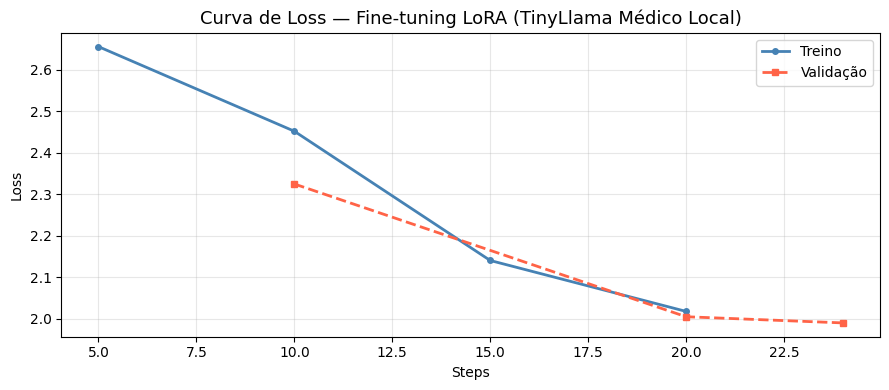

✅ Curva salva em: outputs\tinyllama-medico-local\loss_curve.png


In [11]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_steps  = [e['step'] for e in history if 'loss'      in e]
train_losses = [e['loss'] for e in history if 'loss'      in e]
eval_steps   = [e['step'] for e in history if 'eval_loss' in e]
eval_losses  = [e['eval_loss'] for e in history if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(9, 4))
if train_steps:
    ax.plot(train_steps, train_losses, marker='o', ms=4, color='steelblue',
            linewidth=2, label='Treino')
if eval_steps:
    ax.plot(eval_steps, eval_losses, marker='s', ms=5, color='tomato',
            linewidth=2, linestyle='--', label='Validação')

ax.set_title('Curva de Loss — Fine-tuning LoRA (TinyLlama Médico Local)', fontsize=13)
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

curve_path = OUTPUT_DIR / 'loss_curve.png'
plt.savefig(curve_path, dpi=120)
plt.show()
print(f'✅ Curva salva em: {curve_path}')

## 💾 10. Salvamento do Adapter LoRA

In [12]:
import os

# Salva adapter + tokenizer
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✅ Adapter LoRA salvo em: {OUTPUT_DIR.resolve()}')
print(f'   Arquivos: {os.listdir(OUTPUT_DIR)}')
print(f'   Parâmetros treináveis: {trainable_params:,}')

✅ Adapter LoRA salvo em: C:\Users\Joao Paulo\8iadt-tech-challenge-fase3\outputs\tinyllama-medico-local
   Arquivos: ['adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'checkpoint-24', 'loss_curve.png', 'README.md', 'tokenizer.json', 'tokenizer_config.json']
   Parâmetros treináveis: 2,252,800


## 🧪 11. Avaliação Qualitativa — Antes vs. Depois

Comparação da resposta do modelo **base** (sem fine-tuning) vs. **fine-tunado** para perguntas dos protocolos.

In [13]:
import re

model.config.use_cache = True
model.eval()


def gerar_resposta(pergunta: str, max_new_tokens: int = 200) -> str:
    prompt = (
        "Abaixo está uma instrução que descreve uma tarefa médica hospitalar.\n"
        "Responda em português do Brasil, de forma segura e objetiva.\n"
        "Nunca prescreva medicamento ou dose de forma definitiva.\n"
        "Sempre recomende validação pelo médico responsável.\n\n"
        f"### Instrução:\n{pergunta}\n\n"
        "### Resposta:\n"
    )
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.2,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    # Extrai apenas a parte após '### Resposta:'
    match = re.search(r'### Resposta:\n(.+)', decoded, re.DOTALL)
    return match.group(1).strip() if match else decoded.strip()


PERGUNTAS_TESTE = [
    "Qual é o bundle de 1 hora para manejo inicial de sepse?",
    "Como avaliar dor torácica na emergência nas primeiras horas?",
    "Quais são os critérios diagnósticos de cetoacidose diabética (CAD)?",
]

print('=' * 60)
print('AVALIAÇÃO QUALITATIVA — MODELO FINE-TUNADO')
print('=' * 60)

for i, pergunta in enumerate(PERGUNTAS_TESTE, 1):
    print(f'\n[{i}] Pergunta: {pergunta}')
    print('-' * 50)
    resposta = gerar_resposta(pergunta)
    print(resposta[:500])
    print()

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AVALIAÇÃO QUALITATIVA — MODELO FINE-TUNADO

[1] Pergunta: Qual é o bundle de 1 hora para manejo inicial de sepse?
--------------------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bundle de 1 hora para manejo inicial de sepse:
1. Diagnóstico: se desconhecido ou se não há evidência clínica de sepse.
2. Tratamento: 
   - Hematologia: 
      - Hematocrito > 10%
      - Redução de hemoglobina > 10%
      - Aumento de hemoglobina > 10%
      - Hematocrito > 15%
      - Redução de hemoglobina > 20%
      - Aumento de hemoglobina > 20%
      - Hematocrito > 20%
      - Redução de hemoglobina > 30%
      - Aumento de hemoglobina > 30%
      - Hematocrito >


[2] Pergunta: Como avaliar dor torácica na emergência nas primeiras horas?
--------------------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Avaliar dor torácica na emergência nas primeiras horas:

1. Fase 1:
- Tempo de resposta médica: 15 minutos (10 minutos para o médico responsável).
- Tempo de resposta médica: 15 minutos (10 minutos para o médico responsável).
- Tempo de resposta médica: 30 minutos (15 minutos para o médico responsável).
- Tempo de resposta médica: 60 minutos (30 minutos para o médico responsável).

2. Fase 2:
- Tempo de resposta médica: 30 minutos (15 minutos para o médico responsável).
- Tempo de resposta médic


[3] Pergunta: Quais são os critérios diagnósticos de cetoacidose diabética (CAD)?
--------------------------------------------------
Critérios diagnósticos de CAD:
- HbA1c > 6,5%
- 2 hs-TG > 1,50 mg/dl
- 2 hs-CRP > 1,5 mg/l
- 2 hs-Hb > 10 g/dl
- 2 hs-GGT > 30 U/L
- 2 hs-ALT > 30 U/L
- 2 hs-AST > 30 U/L
- 2 hs-ALB > 3.5 g/dl
- 2 hs-GOT > 30 U/L
- 2 hs-GPT > 30 U/L
- 2 hs-GOT/GPT > 1:100
- 2 hs-



## 🔌 12. Integração com o Assistente (app.py)

Com o adapter salvo em `outputs/tinyllama-medico-local/`, o app já consegue usar o modelo fine-tunado.  
Basta ativar a variável de ambiente `USE_LOCAL_MODEL=true` ou usar o toggle na sidebar do Streamlit.

In [14]:
from pathlib import Path

adapter_path = Path('outputs/tinyllama-medico-local')
required_files = ['adapter_config.json', 'adapter_model.safetensors']

print('=== Verificação do Adapter ===')
all_ok = True
for fname in required_files:
    exists = (adapter_path / fname).exists()
    status = '✅' if exists else '❌'
    print(f'  {status}  {fname}')
    if not exists:
        all_ok = False

if all_ok:
    print('\n✅ Adapter pronto para uso no assistente!')
    print('\nPara usar o modelo fine-tunado no app:')
    print('  Windows (PowerShell):')
    print('    $env:USE_LOCAL_MODEL="true"; streamlit run app.py')
    print('\n  Linux/Mac:')
    print('    USE_LOCAL_MODEL=true streamlit run app.py')
    print('\nOu ative o toggle "🔬 Modelo fine-tunado" na sidebar do app.')
else:
    print('\n⚠️  Execute as células anteriores para gerar o adapter.')

=== Verificação do Adapter ===
  ✅  adapter_config.json
  ✅  adapter_model.safetensors

✅ Adapter pronto para uso no assistente!

Para usar o modelo fine-tunado no app:
  Windows (PowerShell):
    $env:USE_LOCAL_MODEL="true"; streamlit run app.py

  Linux/Mac:
    USE_LOCAL_MODEL=true streamlit run app.py

Ou ative o toggle "🔬 Modelo fine-tunado" na sidebar do app.


## 📋 Resumo Técnico

| Parâmetro | Valor |
|---|---|
| Modelo base | `TinyLlama/TinyLlama-1.1B-Chat-v1.0` |
| Técnica | LoRA (Low-Rank Adaptation) |
| Rank (r) | 8 |
| Módulos alvo | `q_proj, k_proj, v_proj, o_proj` |
| Dataset | 36 pares Q&A extraídos dos 7 protocolos institucionais |
| Idioma | Português do Brasil |
| Épocas | 3 |
| Seq max | 256 tokens |
| Ambiente | CPU local (fp32) / GPU (fp16) |
| Quantização | Nenhuma (sem bitsandbytes) |
| Saída | `outputs/tinyllama-medico-local/` |

### Limitações conhecidas
- Dataset pequeno (~36 exemplos): suficiente para ajuste de estilo e vocabulário, não para raciocínio clínico complexo.
- TinyLlama 1.1B é pequeno — o RAG com FAISS compensa, recuperando os protocolos completos em cada resposta.
- Inferência em CPU é lenta (~30–90s por resposta); recomendado usar Ollama para produção.